In [1]:
# 16 April 2025
# Zachary Katz
# zachary_katz@mines.edu

"""
Plot Figure S2 using output from Figure4.py saved as csv files in the output directory

"""

# Imports and options
import os

import shapefile
import numpy as np
import xarray as xr
import scipy
import skimage
import re
import ast


import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import cartopy.crs as ccrs
import matplotlib.patheffects as pe
from scipy.spatial import cKDTree
from scipy.optimize import curve_fit
import geopandas as gpd
import matplotlib.colors as colors
from matplotlib.lines import Line2D
import matplotlib.cm as cm
from concurrent.futures import ProcessPoolExecutor
import pandas as pd
from pyproj import CRS, Transformer

%matplotlib inline

In [10]:

offset_video_path_1819 = '../_Data/UTG_1819_OffsetVideo'
offset_video_path_1617 = '../_Data/UTG_1617_OffsetVideo'
file_paths_1819 = [os.path.join(offset_video_path_1819, f) for f in os.listdir(offset_video_path_1819) if f.endswith('.nc')]
file_paths_1617 = [os.path.join(offset_video_path_1617, f) for f in os.listdir(offset_video_path_1617) if f.endswith('.nc')]

offset_video_radargrams_1819 = []
for f in file_paths_1819:
    offset_video_radargram = xr.open_dataset(f, decode_timedelta=True)
    offset_video_radargrams_1819.append(offset_video_radargram)

offset_video_radargrams_1819.sort(key=lambda x: x.transect_id)
offset_video_radargrams_1819[0]

offset_video_radargrams_1617 = []
for f in file_paths_1617:
    offset_video_radargram = xr.open_dataset(f, decode_timedelta=True)
    offset_video_radargrams_1617.append(offset_video_radargram)

offset_video_radargrams_1617.sort(key=lambda x: x.transect_id)
offset_video_radargrams_1617[0]


# Remove radargram.transect_id for x in ['X21b', 'X27b'] from offsert_video_radargrams_1819
offset_video_radargrams_1819 = [rg for rg in offset_video_radargrams_1819 if not any(x in rg.transect_id for x in ['X21a', 'X27a'])]

len(offset_video_radargrams_1819), len(offset_video_radargrams_1617)

# Convert from spatial freq width to doppler width
MS_TO_KMHR = 3.6
for radargram in offset_video_radargrams_1819[:]:
    avg_distance = np.mean(np.diff(radargram['distance'].values))

    time = (radargram['time'][-1] - radargram['time'][0])
    time = time / np.timedelta64(1, 's')
    
    velocity = (radargram['distance'][-1] - radargram['distance'][0]).values / time #m/s
    radargram['avg_velocity']  = velocity

    dt = np.gradient(radargram.time.values.astype('datetime64[ns]').astype('int64')) / 1e9 # seconds
    dd = np.gradient(radargram.distance.values) # meters
    radargram['velocity'] = (('distance',), dd/ dt)

for radargram in offset_video_radargrams_1617[:]:
    avg_distance = np.mean(np.diff(radargram['distance'].values))

    time = (radargram['time'][-1] - radargram['time'][0])
    time = time / np.timedelta64(1, 's')
    
    velocity = (radargram['distance'][-1] - radargram['distance'][0]).values / time #m/s
    radargram['avg_velocity']  = velocity

    dt = np.gradient(radargram.time.values.astype('datetime64[ns]').astype('int64')) / 1e9 # seconds
    dd = np.gradient(radargram.distance.values) # meters
    radargram['velocity'] = (('distance',), dd/ dt)


In [12]:
# Load csvs
win_ms = [250, 500, 750,1000,1000, 1250, 1500]  # window length [m]
overlap_ms = [0,250,375,250, 500,625,500]  # overlap [m]

csv_dirs = [f'./output{win}m_win_{overlap}m_ovlp' for win, overlap in zip(win_ms, overlap_ms)]

# Helper functions
def ll2xy(lon: list[float], lat: list[float]) -> tuple[list[float], list[float]]:
    """
    Transform coordinates from input geodetic coordinates (lon, lat)
    to output Antarctic Polar Stereographic coordinates (x, y).
    Can also take single floats.

    Parameters
    ----------
    lon: list[float]
         Geodetic longitude in EPSG:4326
    lat: list[float]
         Geodetic latitude in EPSG:4326

    Returns
    -------
    x: list[float]
       Antarctic Polar Stereographic (EPSG:3031) x
    y: list[float]
       Antarctic Polar Stereographic (EPSG:3031) y
    """

    crs_ll = CRS("EPSG:4326")
    crs_xy = CRS("EPSG:3031")
    ll_to_xy = Transformer.from_crs(crs_ll, crs_xy, always_xy=True)
    x, y = ll_to_xy.transform(lon, lat)
    return x, y
    
def parse_floats(str_list):
    return [float(x) for x in re.findall(r'np\.float64\(([-0-9.eE]+)\)', str_list)]
def parse_arrays(str_list):
    return  [float(x) for x in re.findall(r'array\(([-0-9.eE]+)\)', str_list)]
def parse_ridge_params(str_list):
    str_list = re.sub(r'np\.float64\(([-0-9.eE]+)\)', r'\1', str_list)
    str_list = re.sub(r'np\.int64\(([-0-9]+)\)', r'\1', str_list)
    str_list = re.sub(r'\bnan\b', 'None', str_list)  
     
    return ast.literal_eval(str_list) # Careful with safe parsing

def none_to_nan(dictionary):
    # Recursively replace None with np.nan in dictionary/list
    if isinstance(dictionary, list):
        return [none_to_nan(x) for x in dictionary]

    elif isinstance(dictionary, dict):
        return {k: none_to_nan(v) for k, v in dictionary.items()}

    elif dictionary is None:
        return np.nan

    else:
        return dictionary

In [ ]:
width_arrs_1819 = []
width_arrs_1617 = []

n = 1

for csv_dir in csv_dirs[:n]:
    plotting_dict_1819_csv = pd.read_csv(os.path.join(csv_dir, 'plotting_dict_1819.csv'))
    plotting_dict_1617_csv = pd.read_csv(os.path.join(csv_dir, 'plotting_dict_1617.csv'))

    plotting_dict_1819_csv['x_centers'] = plotting_dict_1819_csv['x_centers'].apply(parse_floats)
    plotting_dict_1819_csv['y_centers'] = plotting_dict_1819_csv['y_centers'].apply(parse_floats)
    plotting_dict_1819_csv['ridge_params_list'] = plotting_dict_1819_csv['ridge_params_list'].apply(parse_ridge_params)
    plotting_dict_1819_csv['velocities'] = plotting_dict_1819_csv['velocities'].apply(parse_arrays)

    plotting_dict_1617_csv['x_centers'] = plotting_dict_1617_csv['x_centers'].apply(parse_floats)
    plotting_dict_1617_csv['y_centers'] = plotting_dict_1617_csv['y_centers'].apply(parse_floats)
    plotting_dict_1617_csv['ridge_params_list'] = plotting_dict_1617_csv['ridge_params_list'].apply(parse_ridge_params)
    plotting_dict_1617_csv['velocities'] = plotting_dict_1617_csv['velocities'].apply(parse_arrays)

    plotting_dict_1819_csv['ridge_params_list'] = plotting_dict_1819_csv['ridge_params_list'].apply(none_to_nan)
    plotting_dict_1617_csv['ridge_params_list'] = plotting_dict_1617_csv['ridge_params_list'].apply(none_to_nan)

    plotting_dict_1819 = plotting_dict_1819_csv.to_dict(orient='list')
    plotting_dict = plotting_dict_1617_csv.to_dict(orient='list')

    velocities_1819 = []
    for radargram, center_list in zip(offset_video_radargrams_1819[:], plotting_dict_1819['x_centers'][:]):
        velocities = []
        for center in center_list[:]:
            idx = np.argmin(np.abs(radargram['x'].compute().values - center))
            velocities.append(radargram['velocity'][idx].values)
        
        velocities_1819.append(velocities)
    
    velocities_1617 = []
    for radargram, center_list in zip(offset_video_radargrams_1617[:], plotting_dict['x_centers'][:]):
        velocities = []
        for center in center_list[:]:
            idx = np.argmin(np.abs(radargram['x'].compute().values - center))
            velocities.append(radargram['velocity'][idx].values)
        
        velocities_1617.append(velocities)  

    plotting_dict_1819['velocities'] = velocities_1819
    plotting_dict['velocities'] = velocities_1617


    widths_for_boxplot_1617 = []
    widths_for_boxplot_1819 = []

    for x_center_list, y_center_list, plotting, velocity in zip(plotting_dict_1819['x_centers'], plotting_dict_1819['y_centers'], plotting_dict_1819['ridge_params_list'], plotting_dict_1819['velocities']):
        width = [rp['right'] - rp['left'] for rp in plotting]
        scaled_width = [w * v for w,v in zip(width,velocity)]  # Scale by velocity to get doppler width
        
        y_maxes = np.array([rp['y_at_max'] for rp in plotting])
        mask = y_maxes < 1250
        scaled_width = np.array([sw.item() for sw in scaled_width])
        scaled_width_masked = scaled_width[~mask]
        widths_for_boxplot_1819.extend(scaled_width_masked)

    for x_center_list, y_center_list, plotting, velocity in zip(plotting_dict['x_centers'], plotting_dict['y_centers'], plotting_dict['ridge_params_list'], plotting_dict['velocities']):
        width = [rp['right'] - rp['left'] for rp in plotting]
        scaled_width = [w * v for w,v in zip(width,velocity)]  # Scale by velocity to get doppler width
        
        y_maxes = np.array([rp['y_at_max'] for rp in plotting])
        mask = y_maxes < 1250
        scaled_width = np.array([sw.item() for sw in scaled_width])
        scaled_width_masked = scaled_width[~mask]
        widths_for_boxplot_1617.extend(scaled_width_masked)


    width_arrs_1819.append(widths_for_boxplot_1819)
    width_arrs_1617.append(widths_for_boxplot_1617)

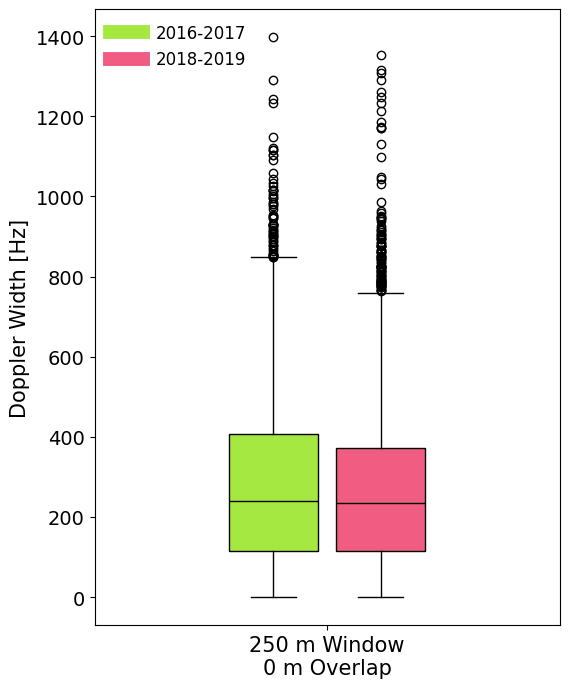

In [ ]:
# Make Boxplot

fig, ax = plt.subplots(figsize=(6, 8))

_1617color = "#a5e841"
_1819color = '#f15d82'
_1617_border = tuple(0.9 * c for c in colors.to_rgb(_1617color))
_1819_border = tuple(0.9 * c for c in colors.to_rgb(_1819color))

pos_1617 = np.arange(1, len(width_arrs_1819) + 1) - 0.15
pos_1819 = np.arange(1, len(width_arrs_1617) + 1) + 0.15

ax.boxplot(
    width_arrs_1617,
    positions=pos_1617,
    widths=0.25,
    patch_artist=True,
    boxprops=dict(facecolor=_1617color, color='black'),
    medianprops=dict(color='black')
)

ax.boxplot(
    width_arrs_1819,
    positions=pos_1819,
    widths=0.25,
    patch_artist=True,
    boxprops=dict(facecolor=_1819color, color='black'),
    medianprops=dict(color='black')
)

# legend
legend_elements = [
    Line2D([0], [0], color=_1617color, lw=10, label='2016-2017'),
    Line2D([0], [0], color=_1819color, lw=10, label='2018-2019'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=12)
legend = ax.get_legend()
legend.get_frame().set_edgecolor('none')

# X axis labels as window and overlap
ax.set_xticks(np.arange(1, len(width_arrs_1819) + 1))
ax.set_xticklabels([f'{win} m Window\n{overlap} m Overlap' for win, overlap in zip(win_ms[:n], overlap_ms[:n])], fontsize=15)
ax.set_ylabel('Doppler Width [Hz]', fontsize=15)
ax.tick_params(axis='y', labelsize=14)